# Tarea 3: Score, difusión y modelos a tiempo continuo
## MDS7203 Modelos Generativos Profundos
### Magíster en Ciencia de Datos - Universidad de Chile
#### Primavera, 2025

---

**Estudiante:** _[Nombre Completo]_

---

## Instrucciones generales

Esta tarea está compuesta por dos partes. En la primera parte se implementará desde cero un modelo de difusión basado en SDEs para un dataset 2D de juguete. En la segunda parte se trabajará con DreamBooth para fine-tuning de modelos de difusión text-to-image.

- El trabajo es individual y debe ser realizado en Google Colab.
- Se pueden usar libremente herramientas como ChatGPT, Gemini o Claude.
- Se debe entregar este notebook completamente ejecutado, y debe poder volver a ejecutarse sin ningún problema.
- Ambas preguntas valen lo mismo (3 puntos c/u).

In [ ]:
!pip install -q git+https://github.com/huggingface/diffusers.git
!pip install -q transformers accelerate peft torchvision ftfy bitsandbytes

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_swiss_roll
from PIL import Image
from diffusers import DiffusionPipeline
from accelerate.utils import write_basic_config

write_basic_config()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Parte 1: Modelos de difusión usando SDEs

El objetivo de esta primera parte es implementar de manera minimal un modelo de difusión basado en SDEs. Para la elección de hiperparámetros, se recomienda dejar los valores indicados por defecto.

### Parte 1.1: Datos de entrenamiento

Como dataset de entrenamiento se utilizará el mismo dataset de juguete usado en clases (Swiss Roll dataset):

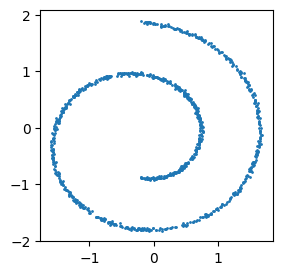

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

# Ejemplo:
samples = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

### Parte 1.2: Clase SDE

El proceso forward en un modelo de difusión a tiempo continuo viene dado por una SDE de la forma

$$\text{d}x = f(x, t)\,\text{d}t + g(t)\,\text{d}w,$$

donde distintas funciones de drift, $f:\mathbb{R}^D\times[0,1]\to\mathbb{R}^D$, y de difusión, $g:[0,1]\to\mathbb{R}$, inducen distintos procesos de difusión. En este caso, se utilizará la _variance preserving SDE_, la cual corresponde a la versión continua del modelo DDPM. Esta SDE considera:

- Drift: $f(x,t) = -\frac{1}{2}\beta(t) x$
- Difusión: $g(t) = \sqrt{\beta(t)}$

con $\beta:[0,1]\to\mathbb{R}$ un scheduler que indica la cantidad de ruido que se va inyectando. En este caso se considerará un scheduler lineal, i.e., $\beta(t) = \beta_{\min} + t(\beta_{\max} - \beta_{\min})$.

Al igual que para DDPM, la distribución $q(x_t | x_0)$ es gaussiana. Más precisamente, se prueba que:

$$x_t = \alpha_t x_0 + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

donde:

$$\alpha_t = \exp\left(-\frac{1}{2}\int_0^t \beta(s)ds\right), \quad \sigma_t = \sqrt{1 - \alpha_t^2}$$

> Implemente los métodos de la clase `SDE` para la VP-SDE. Notar que la integral en $\alpha_t$ es directa cuando se considera $\beta(t) = \beta_{\min} + t(\beta_{\max} - \beta_{\min})$.

In [ ]:
class SDE:

    def __init__(self, beta_min=0.01, beta_max=0.5):
        self.beta_min = beta_min
        self.beta_max = beta_max

    def beta(self, t):
        ...

    def drift(self, x, t):
        ...

    def diffusion(self, t):
        ...

    def alpha(self, t):
        ...

    def sigma(self, t):
        ...

### Parte 1.3: Red neuronal para el score

Dado que se está utilizando un dataset de juguete, es suficiente utilizar una MLP simple para predecir la función de score rescaleado $s_\theta(x, t)$:

In [4]:
class ScoreNetwork(nn.Module):

    def __init__(self, data_dim=2, hidden_dim=128):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(data_dim + 1, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x, t):
        input = torch.cat([x, t.unsqueeze(1)], dim=1)
        return self.model(input)

### Parte 1.4: Entrenamiento con Score Matching

Dado que un modelo de difusión necesita aprender la función de score (para luego usarla en la SDE reversa), la forma natural de entrenar este tipo de modelos es mediante score matching ya que, como se estudió en los modelos score-based, la divergencia de Fisher se puede descomponer en una forma condicional tratable. En este caso, de forma análoga a los modelos de difusión a tiepmo discreto, la función objetivo con la que se entrena la red neuronal asociada al score, $s_\theta:\R^D\times[0,1]\to\R^D$, es:

$$\mathcal{L}(\theta) = \mathbb{E}_{t \sim \text{Uniforme}\left([\epsilon_{\min}, 1]\right), x_0 \sim p_\text{data}(x_0), \epsilon \sim \mathcal{N}(0, \text{I}_D)}\left[\left\| \sigma(t) s_\theta(x_t, t) + \epsilon \right\|^2\right],$$

donde $x_t = \alpha(t) x_0 + \sigma(t) \epsilon$ y $\epsilon_{\min}>0$ es un tiempo mínimo a considerar para evitar problemas numéricos.

> Implemente la función de entrenamiento `train_diffusion_sde` para entrenar el modelo de difusión utilizando la función objetivo anterior.

In [ ]:
def train_diffusion_sde(model, sde, optimizer, iters=5000, eps=1e-5):

    for _ in tqdm(range(iters), desc='Training'):

        x_0 = get_batch()
        
        loss = ...

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Teniendo el bucle de entrenamiento implementado, se puede entrenar el modelo de difusión a tiempo continuo:

In [6]:
model = ScoreNetwork(data_dim=2, hidden_dim=128)
sde = SDE()
optimizer = optim.AdamW(model.parameters())

train_diffusion_sde(model, sde, optimizer)

Training: 100%|██████████| 5000/5000 [00:28<00:00, 177.00it/s]


### Parte 1.5: Generación de nuevas muestras

Para generar muestras se comienza generando un ruido gaussiano $x_1\sim\mathcal{N}(0,\text{I}_D)$ y luego se simula hacia atrás en el tiempo la SDE inversa

$$\text{d}x = \left[f(x,t) - g^2(t) s_\theta(x,t)\right]\,\text{d}t + g(t)\,\text{d}\bar{w},$$

> Implemente la función `generate_samples` que genere nuevas muestras utilizando el algoritmo de Euler-Maruyama para la SDE anterior.

In [ ]:
def generate_samples(model, sde, n_samples=5000, data_dim=2, n_steps=500, eps=1e-5):
    ...

Si todo fue implementado correctamente, la siguiente celda debería mostrar muestras de una distribución similar a la distribución de los datos:

Sampling: 100%|██████████| 500/500 [00:06<00:00, 75.20it/s]


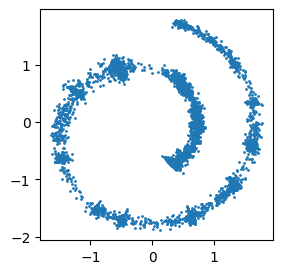

In [ ]:
samples = generate_samples(model, sde)

plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Parte 2: DreamBooth en Stable Diffusion

En esta segunda parte, se utilizará la técnica de DreamBooth, la cual permite personalizar modelos de difusión text-to-image (en este caso, Stable Diffusion) para generar imágenes de un sujeto específico en diferentes contextos.

### Parte 2.1: Datos de entrenamiento

En una carpeta `training_images` ubicada en el mismo directorio que este archivo, coloque un conjunto de imágenes (entre 4 y 10) de un mismo objeto en distintos escenarios. Este objeto debe ser _único_ en el sentido de que muy seguramente Stable Diffusion no lo vio durante su entrenamiento. Estas imágenes serán las que se utilizarán para el fine tuning usando la técnica de DreamBooth.

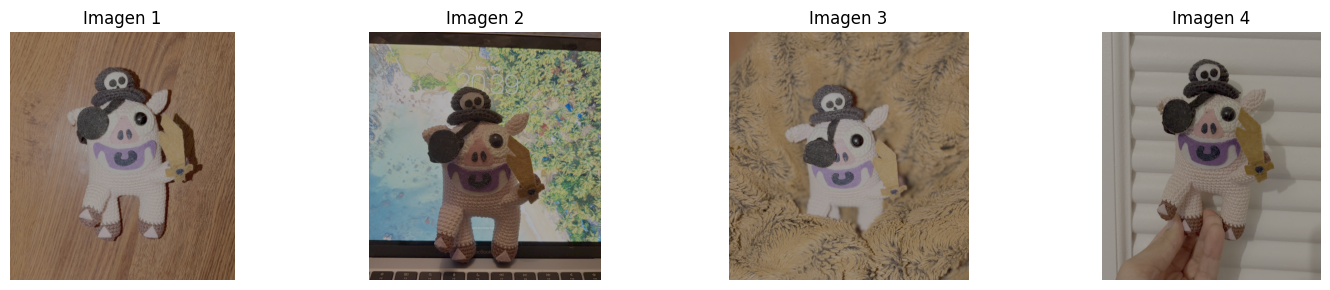

In [9]:
IMAGES_DIR = 'training_images'

image_files = glob.glob(f'{IMAGES_DIR}/*')
image_files = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

fig, axes = plt.subplots(1, min(5, len(image_files)), figsize=(15, 3))
if len(image_files) == 1:
    axes = [axes]

for i, img_path in enumerate(image_files[:5]):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Imagen {i+1}')

plt.tight_layout()
plt.show()

### Parte 2.2: Entrenamiento

Si bien se podría implementar manualmente todo el bucle de fine tuning para DreamBooth + LoRA en Stable Diffusion, se utilizará directamente un [script](https://github.com/huggingface/diffusers/blob/main/examples/dreambooth/train_dreambooth_lora.py) de Hugging Face para el entrenamiento. Notar que la carpeta [examples](https://github.com/huggingface/diffusers/tree/main/examples) contiene muchos scripts para hacer fine tuning sobre distintos modelos de la librería Diffusers, lo cual puede evitar tener que implementar bucles de entrenamiento manualmente.

In [10]:
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py

Si bien el archivo `train_dreambooth_lora.py` es extenso, se pide entender al menos el funcionamiento general del código.

> Responda las siguientes preguntas acerca del script de entrenamiento que se utilizará para DreamBooth:

1. ¿Qué módulos específicos de la U-Net reciben adaptadores LoRA según el código?

2. En el bucle de entrenamiento, ¿qué hace exactamente la línea `model_input = vae.encode(pixel_values).latent_dist.sample()`? ¿Por qué se multiplica después por `vae.config.scaling_factor`?

3. Cuando `args.with_prior_preservation` es `True`, ¿cómo se calcula la pérdida total?

Entrene el modelo Stable Diffusion mediante DreamBooth utilizando el script anterior. Para esto, defina un caption adecuado en la variable `PROMPT` con el formato que propone DreamBooth. Es importante mencionar que aumentando la cantidad de steps de entrenamiento se pueden mejorar considerablemente los resultados.

In [ ]:
PROMPT = ...

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs('output', exist_ok=True)

# Entrenar con DreamBooth + LoRA:
!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path='stable-diffusion-v1-5/stable-diffusion-v1-5' \
  --instance_data_dir={IMAGES_DIR} \
  --output_dir='output' \
  --instance_prompt='{PROMPT}' \
  --resolution=512 \
  --train_batch_size=1 \
  --learning_rate=1e-4 \
  --lr_scheduler=constant \
  --max_train_steps=500 \
  --validation_prompt='{PROMPT}' \
  --validation_epochs=50 \
  --checkpointing_steps=100 \
  --rank=4 \
  --gradient_checkpointing \
  --use_8bit_adam

Una vez terminado el entrenamiento, se cargará el último checkpoint disponible:

In [12]:
pipe = DiffusionPipeline.from_pretrained('stable-diffusion-v1-5/stable-diffusion-v1-5', torch_dtype=torch.float16,safety_checker=None).to('cuda')

checkpoints = sorted(glob.glob(f'output/checkpoint-*'))
pipe.load_lora_weights(checkpoints[-1])

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected:

### Parte 2.3: Generación de imágenes

> Con el adaptador LoRA cargado, genere 5 imágenes donde aparezca el objeto elegido en distintos escenarios.

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

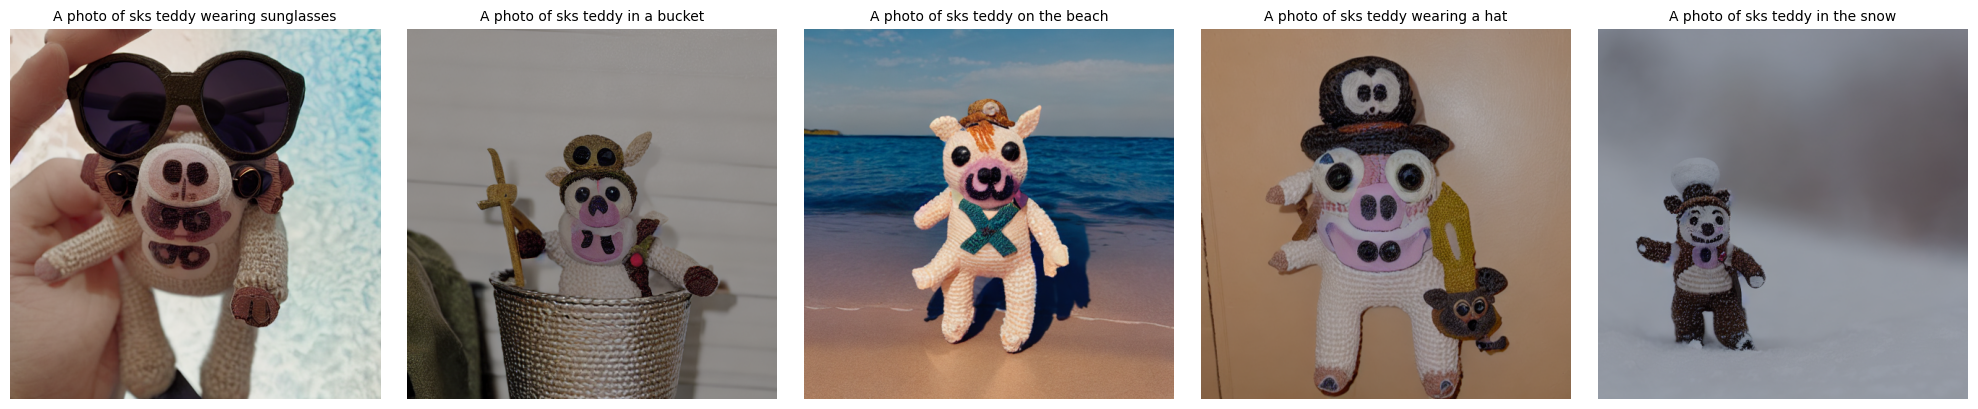

In [ ]:
prompts = [
    '',
    '',
    '',
    '',
    ''
]

# Generación:
images = []
for prompt in prompts:
    image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
    images.append(image)

# Visualización:
fig, axes = plt.subplots(1, len(images), figsize=(4*len(images), 4))
if len(images) == 1:
    axes = [axes]

for i, (img, prompt) in enumerate(zip(images, prompts)):
    axes[i].imshow(img)
    axes[i].set_title(prompt, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()